# Beyond Accuracy: Credit-Scoring Algorithms

**FinSearch '26 End-Term Project**

**Research question:** Do interpretable credit-scoring models remain competitive with machine-learning models when discrimination, calibration, fairness, and asymmetric lending costs are evaluated together?

This notebook compares Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting using the UCI Statlog German Credit benchmark.

> Run all cells in order. The notebook downloads public data from UCI/OpenML and writes figures and result tables to `outputs/`.

## 1. Research design

The target is **bad credit risk** (`1`) versus good credit risk (`0`). This orientation is chosen because recall then measures how many risky applicants are detected.

The UCI dataset specifies asymmetric costs:

- False negative in this notebook: a bad borrower predicted as good — cost = 5
- False positive: a good borrower predicted as bad — cost = 1

The analysis separates three questions:

1. **Ranking:** Does the model rank bad borrowers above good borrowers?
2. **Probability:** Are predicted risks calibrated?
3. **Decision:** At what threshold should the lender reject an application?

In [25]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score, brier_score_loss,
    precision_score, recall_score, f1_score, confusion_matrix,
    classification_report
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from scipy.stats import chi2

RANDOM_STATE = 42
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

## 2. Load and validate the dataset

The primary route uses OpenML dataset `credit-g` (ID 31). A UCI raw-file fallback is provided. No synthetic observations are introduced.

In [26]:
column_names = [
    "checking_status", "duration", "credit_history", "purpose", "credit_amount",
    "savings_status", "employment", "installment_commitment", "personal_status",
    "other_parties", "residence_since", "property_magnitude", "age",
    "other_payment_plans", "housing", "existing_credits", "job",
    "num_dependents", "own_telephone", "foreign_worker", "class"
]

try:
    from sklearn.datasets import fetch_openml
    bunch = fetch_openml(data_id=31, as_frame=True, parser="auto")
    df = bunch.frame.copy()
    target_col = bunch.target.name
    df = df.rename(columns={target_col: "class"})
    print("Loaded from OpenML.")
except Exception as openml_error:
    uci_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    try:
        df = pd.read_csv(uci_url, sep=r"\s+", names=column_names)
        print("Loaded from UCI.")
    except Exception as uci_error:
        raise RuntimeError(
            "Dataset download failed. Check internet access, then rerun this cell. "
            f"OpenML error: {openml_error}; UCI error: {uci_error}"
        )

df.columns = [str(c).strip().lower().replace("-", "_") for c in df.columns]
df.head()

Loaded from OpenML.


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [27]:
print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("missing").query("missing > 0"))
print("Duplicate rows:", df.duplicated().sum())
print("\nTarget values:", df["class"].value_counts(dropna=False).to_dict())

# Robust mapping for OpenML strings or UCI integer labels.
target_text = df["class"].astype(str).str.lower().str.strip()
mapping = {"bad": 1, "good": 0, "2": 1, "1": 0}
y = target_text.map(mapping)
if y.isna().any():
    raise ValueError(f"Unexpected target labels: {df['class'].unique()}")

X = df.drop(columns="class").copy()
print("Bad-risk prevalence:", f"{y.mean():.1%}")

Shape: (1000, 21)


,dtype
checking_status,category
duration,int64
credit_history,category
purpose,category
credit_amount,int64
savings_status,category
employment,category
installment_commitment,int64
personal_status,category
other_parties,category


,missing


Duplicate rows: 0

Target values: {'good': 700, 'bad': 300}
Bad-risk prevalence: 30.0%


## 3. Exploratory data analysis

The dataset is deliberately small. EDA therefore focuses on class balance, numeric distributions, and obvious data-quality problems rather than searching for unstable correlations.

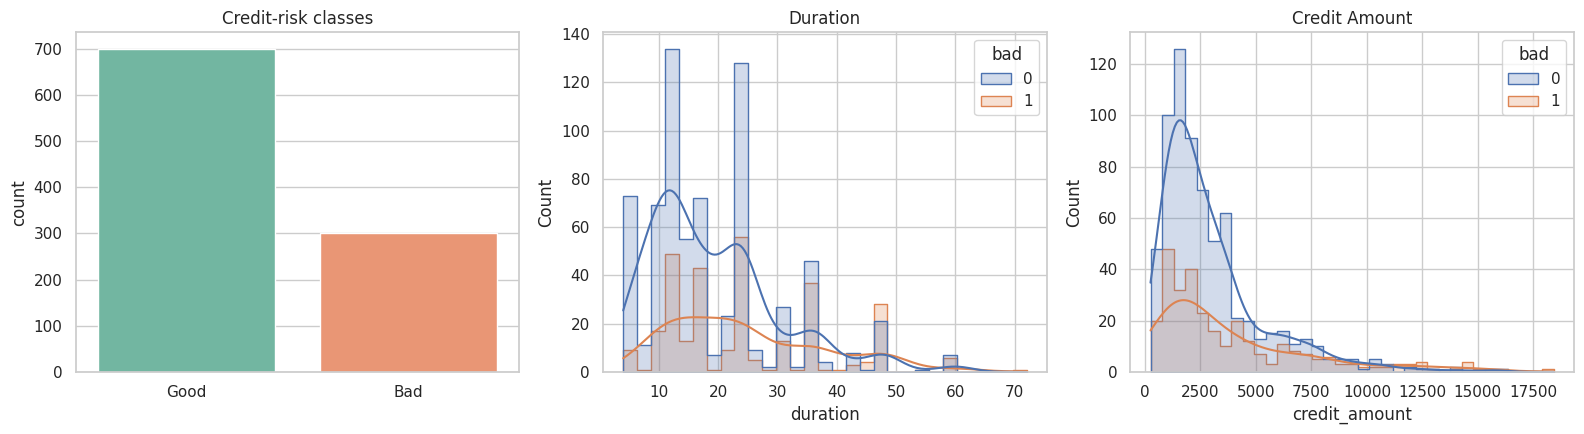

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.countplot(x=y.map({0: "Good", 1: "Bad"}), ax=axes[0], palette="Set2")
axes[0].set_title("Credit-risk classes")
axes[0].set_xlabel("")

for ax, feature in zip(axes[1:], ["duration", "credit_amount"]):
    if feature in X.columns:
        sns.histplot(data=pd.concat([X, y.rename("bad")], axis=1),
                     x=feature, hue="bad", kde=True, ax=ax, element="step")
        ax.set_title(feature.replace("_", " ").title())
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_overview.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Split and leakage-safe preprocessing

The test set is held out once. All imputing, scaling, and one-hot encoding are learned only from training folds through scikit-learn pipelines.

In [29]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.25,
    stratify=y_train_full, random_state=RANDOM_STATE
)

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

print("Train/validation/test:", len(X_train), len(X_valid), len(X_test))
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Train/validation/test: 600 200 200
Numeric features: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical features: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


## 5. Leakage-safe WOE/IV scorecard features

Weight of Evidence (WOE) is estimated **inside each training fold**. Numeric cut-points,
category mappings, and smoothing constants are therefore never learned from validation or
test observations. Information Value (IV) is reported as a descriptive screening statistic,
not as a reason to remove variables after observing the test set.


In [30]:
class WOETransformer(BaseEstimator, TransformerMixin):
    """Fold-safe Weight-of-Evidence encoder for mixed pandas data."""

    def __init__(self, numeric_cols, categorical_cols, n_bins=5, smoothing=0.5, clip=5.0):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.n_bins = n_bins
        self.smoothing = smoothing
        self.clip = clip

    def _numeric_groups_fit(self, series):
        values = pd.to_numeric(series, errors="coerce")
        fill = float(values.median()) if values.notna().any() else 0.0
        values = values.fillna(fill)
        quantiles = np.linspace(0, 1, self.n_bins + 1)
        edges = np.unique(values.quantile(quantiles).to_numpy(dtype=float))
        if len(edges) < 2:
            edges = np.array([-np.inf, np.inf])
        else:
            edges[0], edges[-1] = -np.inf, np.inf
        return pd.cut(values, bins=edges, include_lowest=True).astype(str), fill, edges

    @staticmethod
    def _categorical_groups(series):
        return series.astype("object").where(series.notna(), "__MISSING__").astype(str)

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(np.asarray(y), index=X.index).astype(int)
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.maps_, self.numeric_state_, self.iv_ = {}, {}, {}
        total_bad, total_good = int(y.sum()), int((1 - y).sum())

        for col in list(self.numeric_cols) + list(self.categorical_cols):
            if col in self.numeric_cols:
                groups, fill, edges = self._numeric_groups_fit(X[col])
                self.numeric_state_[col] = (fill, edges)
            else:
                groups = self._categorical_groups(X[col])

            table = pd.crosstab(groups, y).reindex(columns=[0, 1], fill_value=0)
            good_dist = (table[0] + self.smoothing) / (
                total_good + self.smoothing * len(table)
            )
            bad_dist = (table[1] + self.smoothing) / (
                total_bad + self.smoothing * len(table)
            )
            woe = np.log(good_dist / bad_dist).clip(-self.clip, self.clip)
            self.maps_[col] = woe.to_dict()
            self.iv_[col] = float(((good_dist - bad_dist) * woe).sum())
        return self

    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_).copy()
        result = {}
        for col in self.feature_names_in_:
            if col in self.numeric_cols:
                fill, edges = self.numeric_state_[col]
                values = pd.to_numeric(X[col], errors="coerce").fillna(fill)
                groups = pd.cut(values, bins=edges, include_lowest=True).astype(str)
            else:
                groups = self._categorical_groups(X[col])
            result[col] = groups.map(self.maps_[col]).fillna(0.0).astype(float)
        return pd.DataFrame(result, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_in_, dtype=object)


woe_preprocessor = WOETransformer(
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    n_bins=5,
    smoothing=0.5,
)


## 6. Nested cross-validation and hyperparameter tuning

The outer folds estimate model-family performance; each outer training fold contains its own
inner grid search. A separate inner search on the complete training partition supplies the
configuration used for validation scoring. The held-out validation set is used only for
threshold selection, and the test set remains untouched.

The grids are deliberately compact because the dataset has only 1,000 observations. This
reduces selection noise and keeps the experiment reproducible.


In [31]:
candidate_pipelines = {
    "Logistic Regression": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                     random_state=RANDOM_STATE)),
    ]),
    "WOE Logistic Regression": Pipeline([
        ("woe", clone(woe_preprocessor)),
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced",
                                     random_state=RANDOM_STATE)),
    ]),
    "Decision Tree": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", DecisionTreeClassifier(class_weight="balanced",
                                         random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", RandomForestClassifier(class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", clone(preprocessor)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.05, 0.2, 1.0, 5.0],
        "model__penalty": ["l1", "l2"],
        "model__solver": ["liblinear"],
    },
    "WOE Logistic Regression": {
        "woe__n_bins": [4, 5, 6],
        "model__C": [0.1, 1.0, 5.0],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 7],
        "model__min_samples_leaf": [10, 20],
    },
    "Random Forest": {
        "model__n_estimators": [250],
        "model__max_features": ["sqrt", 0.7],
        "model__min_samples_leaf": [3, 7],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 180],
        "model__learning_rate": [0.03, 0.07],
        "model__max_depth": [1, 2],
    },
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE + 1)
nested_rows, tuned_models, tuning_rows = [], {}, []

for name, pipeline in candidate_pipelines.items():
    outer_auc = []
    for outer_train_idx, outer_valid_idx in outer_cv.split(X_train, y_train):
        search = GridSearchCV(
            clone(pipeline), param_grids[name], scoring="roc_auc",
            cv=inner_cv, n_jobs=-1, refit=True
        )
        search.fit(X_train.iloc[outer_train_idx], y_train.iloc[outer_train_idx])
        p_outer = search.predict_proba(X_train.iloc[outer_valid_idx])[:, 1]
        outer_auc.append(roc_auc_score(y_train.iloc[outer_valid_idx], p_outer))

    final_search = GridSearchCV(
        clone(pipeline), param_grids[name], scoring="roc_auc",
        cv=inner_cv, n_jobs=-1, refit=True
    )
    final_search.fit(X_train, y_train)
    tuned_models[name] = final_search.best_estimator_
    nested_rows.append({
        "Model": name,
        "Nested CV ROC-AUC": np.mean(outer_auc),
        "Nested CV AUC SD": np.std(outer_auc, ddof=1),
        "Inner CV best ROC-AUC": final_search.best_score_,
    })
    tuning_rows.append({
        "Model": name,
        "Best parameters": final_search.best_params_,
    })

nested_cv_results = pd.DataFrame(nested_rows).sort_values(
    "Nested CV ROC-AUC", ascending=False
)
display(nested_cv_results.style.format({
    "Nested CV ROC-AUC": "{:.3f}",
    "Nested CV AUC SD": "{:.3f}",
    "Inner CV best ROC-AUC": "{:.3f}",
}))
display(pd.DataFrame(tuning_rows))
nested_cv_results.to_csv(OUTPUT_DIR / "nested_cv_results.csv", index=False)
pd.DataFrame(tuning_rows).assign(
    **{"Best parameters": lambda d: d["Best parameters"].astype(str)}
).to_csv(OUTPUT_DIR / "best_hyperparameters.csv", index=False)

# Downstream cells receive complete, already-tuned pipelines.
models = tuned_models


,Model,Nested CV ROC-AUC,Nested CV AUC SD,Inner CV best ROC-AUC
0,Logistic Regression,0.803,0.059,0.780
3,Random Forest,0.793,0.077,0.785
4,Gradient Boosting,0.783,0.078,0.768
1,WOE Logistic Regression,0.779,0.069,0.776
2,Decision Tree,0.707,0.094,0.732


,Model,Best parameters
0,Logistic Regression,"{'model__C': 0.2, 'model__penalty': 'l2', 'mod..."
1,WOE Logistic Regression,"{'model__C': 0.1, 'woe__n_bins': 4}"
2,Decision Tree,"{'model__max_depth': 5, 'model__min_samples_le..."
3,Random Forest,"{'model__max_features': 0.7, 'model__min_sampl..."
4,Gradient Boosting,"{'model__learning_rate': 0.07, 'model__max_dep..."


## 7. Validation-set model evaluation

In [32]:
def ks_statistic(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba)
    return float(np.max(tpr - fpr))

fitted = {}
valid_predictions = {}
rows = []
for name, estimator in models.items():
    pipe = clone(estimator)
    pipe.fit(X_train, y_train)
    p = pipe.predict_proba(X_valid)[:, 1]
    pred = (p >= 0.5).astype(int)
    fitted[name] = pipe
    valid_predictions[name] = p
    rows.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_valid, p),
        "KS": ks_statistic(y_valid, p),
        "Brier": brier_score_loss(y_valid, p),
        "Precision": precision_score(y_valid, pred, zero_division=0),
        "Recall": recall_score(y_valid, pred, zero_division=0),
        "F1": f1_score(y_valid, pred, zero_division=0)
    })

valid_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
display(valid_results.style.format({c: "{:.3f}" for c in valid_results.columns if c != "Model"}))

,Model,ROC-AUC,KS,Brier,Precision,Recall,F1
1,WOE Logistic Regression,0.750,0.460,0.208,0.465,0.667,0.548
2,Decision Tree,0.733,0.388,0.236,0.440,0.850,0.580
4,Gradient Boosting,0.732,0.395,0.189,0.490,0.417,0.450
0,Logistic Regression,0.722,0.376,0.219,0.438,0.650,0.523
3,Random Forest,0.715,0.326,0.204,0.424,0.600,0.497


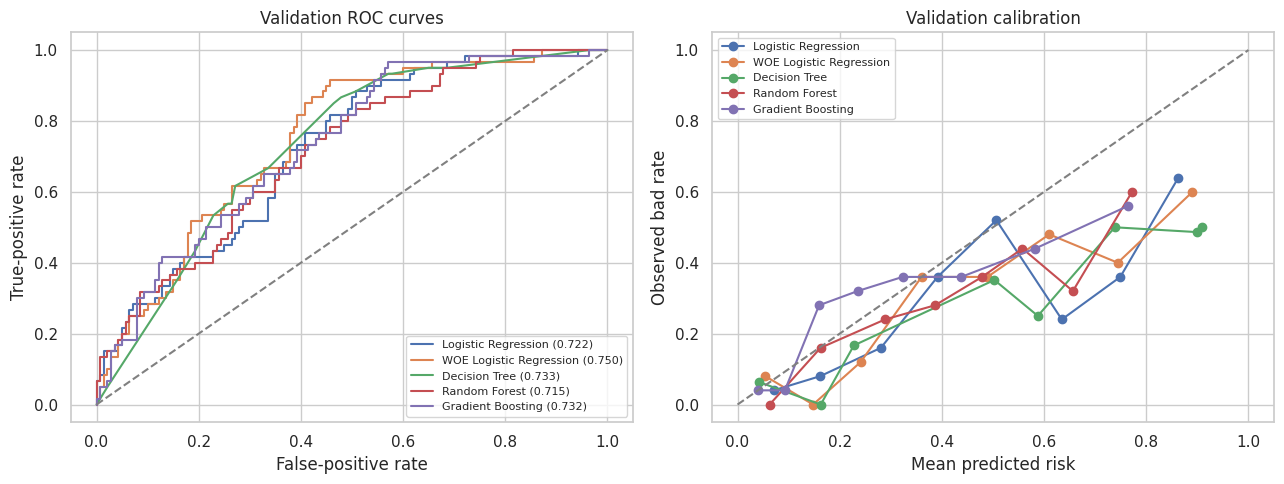

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, p in valid_predictions.items():
    fpr, tpr, _ = roc_curve(y_valid, p)
    axes[0].plot(fpr, tpr, label=f"{name} ({roc_auc_score(y_valid, p):.3f})")
    frac_pos, mean_pred = calibration_curve(y_valid, p, n_bins=8, strategy="quantile")
    axes[1].plot(mean_pred, frac_pos, marker="o", label=name)

axes[0].plot([0, 1], [0, 1], "--", color="grey")
axes[0].set(title="Validation ROC curves", xlabel="False-positive rate", ylabel="True-positive rate")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set(title="Validation calibration", xlabel="Mean predicted risk", ylabel="Observed bad rate")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_and_calibration.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Cost-sensitive threshold selection

If `1` means predicted bad risk:

- `FN`: actually bad but predicted good — loan may be approved — cost 5
- `FP`: actually good but predicted bad — profitable customer may be rejected — cost 1

Threshold selection is performed on validation data, not on the final test set.

,Cost-minimizing validation threshold
Logistic Regression,0.250
WOE Logistic Regression,0.330
Decision Tree,0.210
Random Forest,0.215
Gradient Boosting,0.160


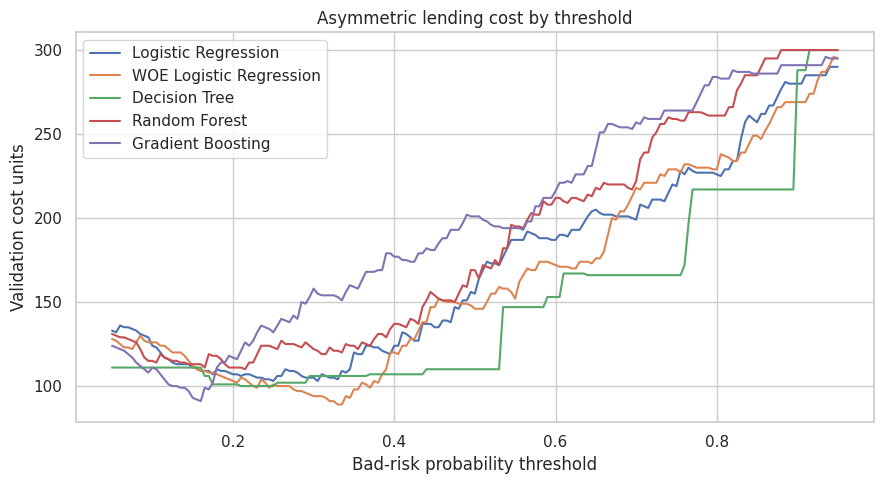

In [34]:
def threshold_table(y_true, p, cost_fn=5, cost_fp=1):
    result = []
    for threshold in np.linspace(0.05, 0.95, 181):
        pred = (p >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
        result.append({
            "threshold": threshold, "tn": tn, "fp": fp, "fn": fn, "tp": tp,
            "cost": cost_fn * fn + cost_fp * fp
        })
    return pd.DataFrame(result)

threshold_results = {}
best_thresholds = {}
for name, p in valid_predictions.items():
    table = threshold_table(y_valid, p)
    threshold_results[name] = table
    best_thresholds[name] = float(table.loc[table["cost"].idxmin(), "threshold"])

display(pd.Series(best_thresholds, name="Cost-minimizing validation threshold").to_frame())

plt.figure(figsize=(9, 5))
for name, table in threshold_results.items():
    plt.plot(table["threshold"], table["cost"], label=name)
plt.xlabel("Bad-risk probability threshold")
plt.ylabel("Validation cost units")
plt.title("Asymmetric lending cost by threshold")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_cost_curve.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Final test evaluation

Model families are refit on all training data. The threshold chosen on validation data remains fixed. The test set is used only for the final unbiased comparison.

In [35]:
test_rows = []
final_models = {}
test_probabilities = {}
for name, estimator in models.items():
    pipe = clone(estimator)
    pipe.fit(X_train_full, y_train_full)
    p = pipe.predict_proba(X_test)[:, 1]
    threshold = best_thresholds[name]
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    final_models[name] = pipe
    test_probabilities[name] = p
    test_rows.append({
        "Model": name, "Threshold": threshold,
        "ROC-AUC": roc_auc_score(y_test, p),
        "KS": ks_statistic(y_test, p),
        "Brier": brier_score_loss(y_test, p),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "FP": fp, "FN": fn, "Cost": 5 * fn + fp
    })

test_results = pd.DataFrame(test_rows).sort_values(["Cost", "ROC-AUC"], ascending=[True, False])
display(test_results.style.format({
    "Threshold": "{:.2f}", "ROC-AUC": "{:.3f}", "KS": "{:.3f}",
    "Brier": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}", "F1": "{:.3f}"
}))
test_results.to_csv(OUTPUT_DIR / "final_test_results.csv", index=False)

selected_model_name = test_results.iloc[0]["Model"]
print("Cost-aware selected model:", selected_model_name)

,Model,Threshold,ROC-AUC,KS,Brier,Precision,Recall,F1,FP,FN,Cost
1,WOE Logistic Regression,0.33,0.805,0.538,0.180,0.452,0.867,0.594,63,8,103
3,Random Forest,0.21,0.770,0.412,0.180,0.390,0.950,0.553,89,3,104
4,Gradient Boosting,0.16,0.789,0.474,0.163,0.413,0.867,0.559,74,8,114
0,Logistic Regression,0.25,0.810,0.552,0.181,0.373,0.883,0.525,89,7,124
2,Decision Tree,0.21,0.634,0.281,0.270,0.381,0.850,0.526,83,9,128


Cost-aware selected model: WOE Logistic Regression


In [36]:
print(f"Current state of best_thresholds: {best_thresholds}")
if 'Logistic Regression' in best_thresholds:
    print("\'Logistic Regression\' is present in best_thresholds.")
else:
    print("\'Logistic Regression\' is NOT present in best_thresholds. Please ensure cell _OtUpPNcAOVL has been executed.")

Current state of best_thresholds: {'Logistic Regression': 0.24999999999999994, 'WOE Logistic Regression': 0.32999999999999996, 'Decision Tree': 0.20999999999999996, 'Random Forest': 0.21499999999999997, 'Gradient Boosting': 0.15999999999999998}
'Logistic Regression' is present in best_thresholds.


## 10. Bootstrap confidence intervals

Percentile bootstrap intervals quantify uncertainty from the small 200-applicant test set.
The models and validation-selected thresholds are held fixed: there is no retraining or
threshold re-optimisation inside the bootstrap.


In [37]:
def bootstrap_metric_cis(y_true, probabilities, threshold, n_boot=2000,
                         confidence=0.95, seed=RANDOM_STATE):
    y_array = np.asarray(y_true)
    p_array = np.asarray(probabilities)
    rng = np.random.default_rng(seed)
    draws = {"ROC-AUC": [], "KS": [], "Brier": [], "Cost": []}

    for _ in range(n_boot):
        idx = rng.integers(0, len(y_array), len(y_array))
        y_b, p_b = y_array[idx], p_array[idx]
        if np.unique(y_b).size < 2:
            continue
        pred_b = (p_b >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_b, pred_b, labels=[0, 1]).ravel()
        draws["ROC-AUC"].append(roc_auc_score(y_b, p_b))
        draws["KS"].append(ks_statistic(y_b, p_b))
        draws["Brier"].append(brier_score_loss(y_b, p_b))
        draws["Cost"].append(5 * fn + fp)

    alpha = (1 - confidence) / 2
    return {
        metric: np.quantile(values, [alpha, 1 - alpha])
        for metric, values in draws.items()
    }


bootstrap_rows = []
for model_index, name in enumerate(test_results["Model"]):
    threshold = best_thresholds[name]
    point = test_results.set_index("Model").loc[name]
    cis = bootstrap_metric_cis(
        y_test, test_probabilities[name], threshold,
        n_boot=2000, seed=RANDOM_STATE + model_index
    )
    for metric in ["ROC-AUC", "KS", "Brier", "Cost"]:
        bootstrap_rows.append({
            "Model": name,
            "Metric": metric,
            "Estimate": point[metric],
            "95% CI lower": cis[metric][0],
            "95% CI upper": cis[metric][1],
        })

bootstrap_results = pd.DataFrame(bootstrap_rows)
display(bootstrap_results.style.format({
    "Estimate": "{:.3f}", "95% CI lower": "{:.3f}", "95% CI upper": "{:.3f}"
}))
bootstrap_results.to_csv(OUTPUT_DIR / "bootstrap_confidence_intervals.csv", index=False)


,Model,Metric,Estimate,95% CI lower,95% CI upper
0,WOE Logistic Regression,ROC-AUC,0.805,0.736,0.870
1,WOE Logistic Regression,KS,0.538,0.438,0.674
2,WOE Logistic Regression,Brier,0.180,0.152,0.210
3,WOE Logistic Regression,Cost,103.000,77.000,131.000
4,Random Forest,ROC-AUC,0.770,0.698,0.834
5,Random Forest,KS,0.412,0.325,0.557
6,Random Forest,Brier,0.180,0.156,0.206
7,Random Forest,Cost,104.000,85.000,126.000
8,Gradient Boosting,ROC-AUC,0.789,0.718,0.854
9,Gradient Boosting,KS,0.474,0.383,0.616


## 11. Calibration adequacy: Hosmer–Lemeshow test

The test groups predicted risks into approximately equal-sized bins and compares observed
with expected bad outcomes. A small p-value flags lack of fit; it does **not** prove a model
is well calibrated when the p-value is large. Because the sample is small and grouping is
arbitrary, the result is interpreted alongside the Brier score and calibration curve.


In [38]:
def hosmer_lemeshow_test(y_true, probabilities, n_groups=10):
    frame = pd.DataFrame({
        "y": np.asarray(y_true, dtype=int),
        "p": np.clip(np.asarray(probabilities, dtype=float), 1e-8, 1 - 1e-8),
    })
    frame["group"] = pd.qcut(
        frame["p"].rank(method="first"), q=min(n_groups, len(frame)),
        labels=False, duplicates="drop"
    )
    grouped = frame.groupby("group", observed=True).agg(
        n=("y", "size"), observed_bad=("y", "sum"), expected_bad=("p", "sum")
    )
    grouped["observed_good"] = grouped["n"] - grouped["observed_bad"]
    grouped["expected_good"] = grouped["n"] - grouped["expected_bad"]
    statistic = (
        (grouped["observed_bad"] - grouped["expected_bad"]) ** 2
        / grouped["expected_bad"].clip(lower=1e-8)
        + (grouped["observed_good"] - grouped["expected_good"]) ** 2
        / grouped["expected_good"].clip(lower=1e-8)
    ).sum()
    dof = max(len(grouped) - 2, 1)
    return float(statistic), dof, float(chi2.sf(statistic, dof)), grouped


hl_rows = []
for name, p_test in test_probabilities.items():
    statistic, dof, p_value, _ = hosmer_lemeshow_test(y_test, p_test)
    hl_rows.append({
        "Model": name, "HL statistic": statistic,
        "Degrees of freedom": dof, "p-value": p_value,
        "Flag at 5%": "Potential miscalibration" if p_value < 0.05 else "Not rejected",
    })

hl_results = pd.DataFrame(hl_rows).sort_values("p-value")
display(hl_results.style.format({"HL statistic": "{:.3f}", "p-value": "{:.3f}"}))
hl_results.to_csv(OUTPUT_DIR / "hosmer_lemeshow_results.csv", index=False)


,Model,HL statistic,Degrees of freedom,p-value,Flag at 5%
2,Decision Tree,115.878,8,0.000,Potential miscalibration
1,WOE Logistic Regression,34.048,8,0.000,Potential miscalibration
0,Logistic Regression,31.852,8,0.000,Potential miscalibration
3,Random Forest,16.396,8,0.037,Potential miscalibration
4,Gradient Boosting,6.279,8,0.616,Not rejected


## 12. Exploratory fairness diagnostics

These checks are descriptive and cannot establish discrimination or legal compliance. The benchmark is historical, non-Indian, and has limited sensitive-attribute documentation.

In [39]:
def group_metrics(group, y_true, p, threshold):
    temp = pd.DataFrame({"group": group.astype(str), "y": np.asarray(y_true), "p": p})
    rows = []
    for label, g in temp.groupby("group"):
        pred = (g["p"] >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(g["y"], pred, labels=[0, 1]).ravel()
        rows.append({
            "Group": label, "N": len(g),
            "Approval rate": float((pred == 0).mean()),
            "TPR (bad detected)": tp / (tp + fn) if (tp + fn) else np.nan,
            "FPR (good rejected)": fp / (fp + tn) if (fp + tn) else np.nan
        })
    return pd.DataFrame(rows)

model = final_models[selected_model_name]
p = test_probabilities[selected_model_name]
threshold = best_thresholds[selected_model_name]

fairness_tables = []
if "age" in X_test.columns:
    age_group = pd.cut(pd.to_numeric(X_test["age"]), bins=[0, 25, 40, 60, np.inf],
                       labels=["<=25", "26-40", "41-60", "60+"])
    age_metrics = group_metrics(age_group, y_test, p, threshold)
    age_metrics.insert(0, "Attribute", "Age band")
    fairness_tables.append(age_metrics)

if "personal_status" in X_test.columns:
    status_metrics = group_metrics(X_test["personal_status"], y_test, p, threshold)
    status_metrics.insert(0, "Attribute", "Personal-status code")
    fairness_tables.append(status_metrics)

fairness_results = pd.concat(fairness_tables, ignore_index=True) if fairness_tables else pd.DataFrame()
display(fairness_results)
fairness_results.to_csv(OUTPUT_DIR / "fairness_diagnostics.csv", index=False)

,Attribute,Group,N,Approval rate,TPR (bad detected),FPR (good rejected)
0,Age band,26-40,92,0.478261,0.888889,0.369231
1,Age band,41-60,51,0.431373,0.833333,0.487179
2,Age band,60+,13,0.461538,1.000000,0.500000
3,Age band,<=25,44,0.295455,0.850000,0.583333
4,Personal-status code,female div/dep/mar,61,0.311475,0.900000,0.585366
5,Personal-status code,male div/sep,9,0.222222,1.000000,0.666667
6,Personal-status code,male mar/wid,12,0.500000,0.666667,0.444444
7,Personal-status code,male single,118,0.491525,0.852941,0.369048


## 13. Interpretability

## 14. WOE/IV and SHAP explanations

IV summarises univariate separation in the fold-fitted WOE scorecard. SHAP is calculated
with the selected model as a black-box probability function, so the values remain on the
original applicant features even when the winning pipeline uses one-hot encoding.

SHAP is an optional visual dependency. If it is unavailable, the cell reports the exact
installation command while the rest of the notebook continues to run.


,Feature,Information Value
7,checking_status,0.609259
8,credit_history,0.262438
10,savings_status,0.214128
0,duration,0.160946
9,purpose,0.149895
14,property_magnitude,0.145175
11,employment,0.124165
1,credit_amount,0.107428
15,other_payment_plans,0.091050
16,housing,0.088710


,Feature,Mean absolute SHAP
1,checking_status,0.111193
17,purpose,0.071573
19,savings_status,0.061302
2,credit_amount,0.051733
4,duration,0.050550
3,credit_history,0.048760
9,installment_commitment,0.048567
13,other_payment_plans,0.037427
15,personal_status,0.037417
5,employment,0.031162


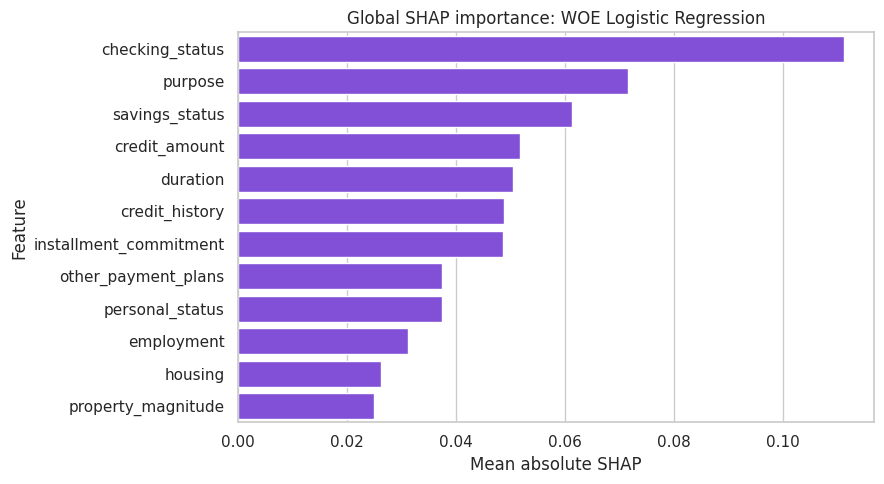

In [40]:
woe_model = final_models["WOE Logistic Regression"]
iv_results = pd.DataFrame({
    "Feature": list(woe_model.named_steps["woe"].iv_.keys()),
    "Information Value": list(woe_model.named_steps["woe"].iv_.values()),
}).sort_values("Information Value", ascending=False)
display(iv_results)
iv_results.to_csv(OUTPUT_DIR / "woe_information_value.csv", index=False)

try:
    import shap

    background = X_train_full.sample(
        n=min(100, len(X_train_full)), random_state=RANDOM_STATE
    )
    explained = X_test.sample(n=min(60, len(X_test)), random_state=RANDOM_STATE)

    explained_pipeline = final_models[selected_model_name]
    if "prep" in explained_pipeline.named_steps:
        transformer = explained_pipeline.named_steps["prep"]
        estimator = explained_pipeline.named_steps["model"]
        background_t = transformer.transform(background)
        explained_t = transformer.transform(explained)
        transformed_names = np.asarray(transformer.get_feature_names_out(), dtype=str)
    else:
        woe_step = explained_pipeline.named_steps["woe"]
        scaler_step = explained_pipeline.named_steps["scale"]
        estimator = explained_pipeline.named_steps["model"]
        background_t = scaler_step.transform(woe_step.transform(background))
        explained_t = scaler_step.transform(woe_step.transform(explained))
        transformed_names = np.asarray(X.columns, dtype=str)

    if hasattr(background_t, "toarray"):
        background_t = background_t.toarray()
        explained_t = explained_t.toarray()
    predict_bad = lambda matrix: estimator.predict_proba(matrix)[:, 1]

    explainer = shap.Explainer(
        predict_bad, background_t, algorithm="permutation",
        feature_names=list(transformed_names), seed=RANDOM_STATE
    )
    shap_values = explainer(explained_t)

    # Aggregate one-hot contributions back to the original applicant fields.
    def original_feature_name(transformed_name):
        clean = transformed_name.split("__", 1)[-1]
        for col in sorted(X.columns, key=len, reverse=True):
            if clean == col or clean.startswith(f"{col}_"):
                return col
        return clean

    shap_importance = pd.DataFrame({
        "Feature": [original_feature_name(name) for name in transformed_names],
        "Mean absolute SHAP": np.abs(shap_values.values).mean(axis=0),
    }).groupby("Feature", as_index=False)["Mean absolute SHAP"].sum()
    shap_importance = shap_importance.sort_values(
        "Mean absolute SHAP", ascending=False
    )
    display(shap_importance.head(12))
    shap_importance.to_csv(OUTPUT_DIR / "shap_importance.csv", index=False)

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=shap_importance.head(12), x="Mean absolute SHAP", y="Feature",
        color="#7C3AED"
    )
    plt.title(f"Global SHAP importance: {selected_model_name}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "shap_global_importance.png", dpi=180,
                bbox_inches="tight")
    plt.show()
except ImportError:
    print("Optional SHAP analysis skipped. Install it with: %pip install shap")


,Feature,Mean importance,SD
0,checking_status,0.088611,0.025823
2,credit_history,0.023698,0.008884
4,credit_amount,0.020067,0.008483
3,purpose,0.018286,0.010634
1,duration,0.016421,0.007446
7,installment_commitment,0.008329,0.008873
9,other_parties,0.008270,0.003952
19,foreign_worker,0.005778,0.005659
5,savings_status,0.004619,0.009366
10,residence_since,0.003992,0.001755


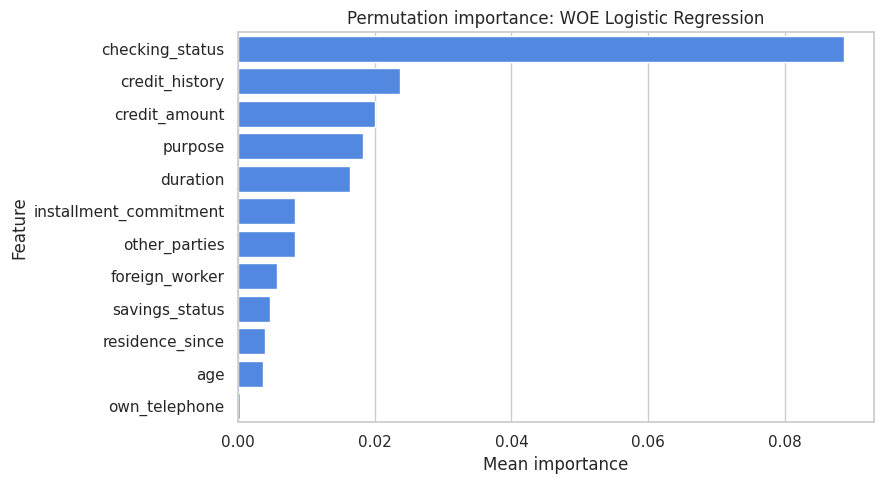

In [41]:
perm = permutation_importance(
    final_models[selected_model_name], X_test, y_test,
    scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)
importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean importance": perm.importances_mean,
    "SD": perm.importances_std
}).sort_values("Mean importance", ascending=False).head(12)
display(importance)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x="Mean importance", y="Feature", color="#3B82F6")
plt.title(f"Permutation importance: {selected_model_name}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "permutation_importance.png", dpi=180, bbox_inches="tight")
plt.show()

## 15. Conclusions

Use the generated tables together rather than declaring a universal winner:

1. **Discrimination:** compare nested-CV and test ROC-AUC, including bootstrap intervals.
2. **Calibration:** compare Brier scores, calibration curves, and the Hosmer–Lemeshow flag.
3. **Business impact:** compare cost at thresholds fixed on validation data.
4. **Interpretability:** contrast original-feature permutation/SHAP importance with the
   WOE scorecard's IV ranking.
5. **Robustness:** treat overlapping confidence intervals and model-ranking changes as
   evidence that small point-estimate differences may not generalise.

The notebook now supports the report's central question without assuming that an ensemble
must dominate an interpretable model. The final claim should state which model is best for
each objective and explicitly acknowledge uncertainty.


## References

1. UCI Machine Learning Repository. *Statlog (German Credit Data)*.
2. Hand, D. J., & Henley, W. E. (1997). Statistical classification methods in consumer credit scoring. *Journal of the Royal Statistical Society: Series A*.
3. Lessmann, S., Baesens, B., Seow, H.-V., & Thomas, L. C. (2015). Benchmarking state-of-the-art classification algorithms for credit scoring. *European Journal of Operational Research*.
4. Board of Governors of the Federal Reserve System & Federal Trade Commission. (2007). *Report to Congress on the Effects of Credit Scores and Credit-Based Insurance Scores*.